In [1]:
import sys
sys.path.insert(0, f'../gigalens/src')

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import jax
import jax.numpy as jnp
import optax
import tensorflow_probability.substrates.jax as tfp
tfd = tfp.distributions

from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic
from gigalens.jax.profiles.mass import epl, shear

from astropy.io import fits
from astropy.visualization import simple_norm

obs = np.array(np.load('./imL.npy')).astype(np.float32)
norm = simple_norm(obs, 'sqrt', percent=99.)
kernel = np.array(np.load('./psf.npy')).astype(np.float32)

data94 = fits.open("final_94_drz.fits")
image94 = data94[1].data
exp_time = data94[0].header["EXPTIME"]
data94.close()

lens_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                theta_E=tfd.LogNormal(jnp.log(1.5), 0.25),
                gamma=tfd.TruncatedNormal(2, 0.25, 1, 3),
                e1=tfd.Normal(0, 0.1),
                e2=tfd.Normal(0, 0.1),
                center_x=tfd.Normal(-0.3, 0.15),
                center_y=tfd.Normal(-0.1, 0.15),
            )
        ),
        tfd.JointDistributionNamed(
            dict(gamma1=tfd.Normal(0, 0.15), gamma2=tfd.Normal(0, 0.15))
        ),
    ]
)
lens_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.2), 0.15),
                n_sersic=tfd.Uniform(3, 8),
                e1=tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
                center_x=tfd.Normal(-3.4, 0.25),
                center_y=tfd.Normal(-3.1, 0.25)
            )
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.0), 0.15),
                n_sersic=tfd.Uniform(2, 6),
                e1=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                e2=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                center_x=tfd.Normal(-0.3, 0.05),
                center_y=tfd.Normal(-0.1, 0.05)
            )
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.0), 0.15),
                n_sersic=tfd.Uniform(1, 3),
                e1=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                e2=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                center_x=tfd.Normal(-0.3, 0.05),
                center_y=tfd.Normal(-0.1, 0.05)
            )
        )
    ]
)

source_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.25), 0.15),
                n_sersic=tfd.Uniform(0.5, 4),
                e1=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                center_x=tfd.Normal(-0.2, 0.25),
                center_y=tfd.Normal(-0.2, 0.25)
            )
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.25), 0.15),
                n_sersic=tfd.Uniform(0.1, 0.5),
                e1=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                center_x=tfd.Normal(0.2, 0.25),
                center_y=tfd.Normal(0, 0.25)
            )
        )
    ]
)

prior = tfd.JointDistributionSequential(
    [lens_prior, lens_light_prior, source_light_prior]
)
sim_config = SimulatorConfig(delta_pix=0.065, num_pix=100, supersample=2, kernel=kernel)
phys_model = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=True),sersic.SersicEllipse(use_lstsq=True),sersic.SersicEllipse(use_lstsq=True)], [sersic.SersicEllipse(use_lstsq=True), sersic.SersicEllipse(use_lstsq=True)])
lens_sim = LensSimulator(phys_model, sim_config, bs=1)
prob_model = BackwardProbModel(prior, jnp.array(obs), background_rms=0.007616, exp_time=exp_time)
model_seq = ModellingSequence(phys_model, prob_model, sim_config)

schedule_fn = optax.polynomial_schedule(init_value=-0.01, end_value=-0.003, 
                                      power=0.1, transition_steps=1000)
opt = optax.chain(
  optax.scale_by_adam(),
  optax.scale_by_schedule(schedule_fn),
)
map_estimate = model_seq.MAP_multi(opt, seed=0, num_steps=350)

2025-12-16 11:06:19.077885: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765911979.616224 1993752 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765911979.769571 1993752 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765911981.464268 1993752 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765911981.464290 1993752 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765911981.464292 1993752 computation_placer.cc:177] computation placer alr

In [3]:
lps = prob_model.log_prob(LensSimulator(phys_model, sim_config, bs=500), map_estimate[0])[0]
best = map_estimate[jnp.argmax(lps)][jnp.newaxis,:]

2025-12-16 11:08:16.088771: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng28{k2=3,k3=0} for conv %cudnn-conv.1 = (f32[500,5,200,200]{3,2,1,0}, u8[0]{0}) custom-call(%select.585, %constant.7833), window={size=53x53 pad=26_26x26_26}, dim_labels=bf01_oi01->bf01, feature_group_count=5, custom_call_target="__cudnn$convForward", metadata={op_name="jit(log_prob)/jit(main)/jit(lstsq_simulate)/conv_general_dilated" source_file="/global/u1/c/chaseg/desi-238/../gigalens/src/gigalens/jax/simulator.py" source_line=118}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-12-16 11:08:19.520035: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 4.431387663s
Trying algorithm eng28{k2=3,k3=0} for conv %cudnn-conv.1 = (f32[500,5,200,20

2025-12-16 11:09:40.682640: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-12-16 11:09:40.682776: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-12-16 11:09:43.626980: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng28{k2=3,k3=0} for conv %cudnn-conv.2 = (f32[250,5,200,200]{3,2,1,0}, u8[0]{0}) custom-call(%select.4145, %constant.10105), window={size=53x53 pad=26_26x26_26}, dim_labels=bf01_oi01->bf01, feature_group_count=5, custom_call_target="__cudnn$convForward", metadata={op_name=

Text(0.5, 1.0, 'Loss')

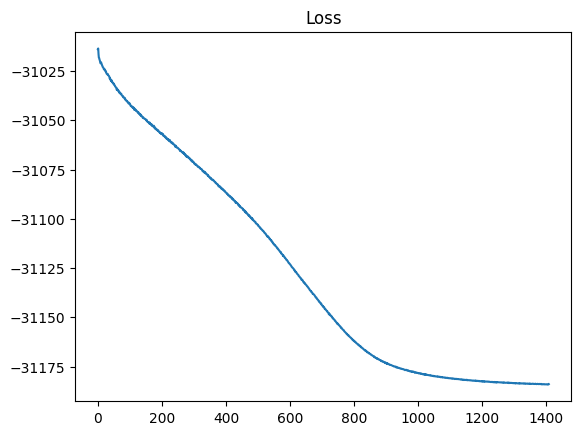

In [4]:
opt = optax.adabelief(1e-4, b1=0.95, b2=0.99)
# possibly adabelief issue
# schedule_fn = optax.polynomial_schedule(init_value=-1e-7, end_value=-3e-2, power=2, transition_steps=300)
# opt = optax.chain(
#   optax.scale_by_adam(),
#   optax.scale_by_schedule(schedule_fn),
# )
# #
qz, loss_hist = model_seq.SVI_multi(best, opt, n_vi=1000, num_steps=2500)

plt.plot(loss_hist)
plt.title('Loss')

In [16]:
samples = model_seq.HMC_multi(qz, num_burnin_steps=500, num_results=750)

In [ ]:
rhat = tfp.mcmc.potential_scale_reduction(jnp.transpose(samples, (2,0,1,3)), independent_chain_ndims=2) # cross_chain_dims=(1,2)
plt.plot(rhat)
plt.title('rhat')

In [ ]:
from corner import corner

smp = jnp.transpose(samples, (1, 2, 0, 3)).reshape((-1, len(rhat)))
smp_physical = prob_model.bij.forward(list(smp.T))

def get_corner_samples(physical, key):
    """
    Key tells you lens_mass (1), lens_light (2), or source_light (3)
    """
    return_list = []

    if key == 1:
        for i in physical[0][0].keys():
            return_list.append(physical[0][0][i])
        for j in physical[0][1].keys():
            return_list.append(physical[0][1][j])

    if key == 2:
        for i in physical[1][0].keys():
            return_list.append(physical[1][0][i])

    if key == 3:
        for i in physical[2][0].keys():
            return_list.append(physical[2][0][i])
            
    return np.stack(return_list).T

mass_samps = get_corner_samples(smp_physical, 1)

plt.style.use('default')

labels=[r'$\theta_E$', 
        r'$\gamma$', 
        r'$\epsilon_1$', 
        r'$\epsilon_2$', 
        r'$x$', r'$y$', 
        r'$\gamma_{1,ext}$', 
        r'$\gamma_{2,ext}$']

fig = corner(mass_samps, show_titles=True, title_fmt='.3f', labels=labels)
_ = fig.suptitle("Lens Parameters")

In [ ]:
tups = [(0, 0), (0, 1), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1)]
label_prefixes = ["", "", "otherobj_", "lens1_", "lens2_", "src1_", "src2_"]
labels = []
for (i, j), label_prefix in zip(tups, label_prefixes):
    labels.extend((label_prefix + key for key in smp_physical[i][j].keys()))

plt.style.use('default')

plt_samples = np.vstack(
    [np.array(list(smp_physical[i][j].values())) for i, j in tups]
).T
fig = corner(
    plt_samples,
    show_titles=True,
    title_fmt=".3f",
    labels=labels
)
_ = fig.suptitle("All Parameters")
plt.show()

0.92000586


[]

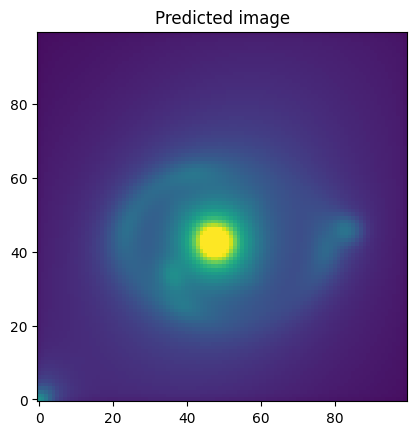

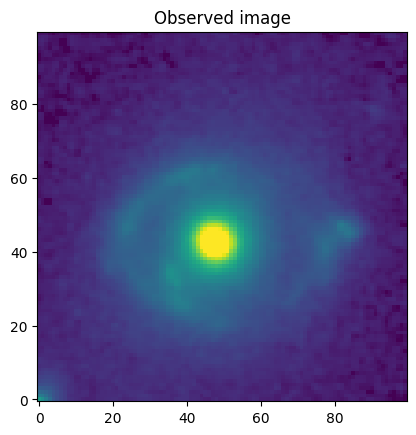

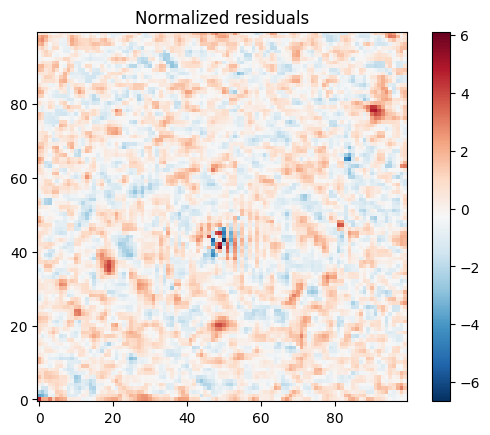

In [9]:
physical = prob_model.bij.forward(list(best.T))
err_map = np.sqrt(0.007616**2 + obs/exp_time)
simulated = lens_sim.lstsq_simulate(physical, jnp.array(obs), err_map)
norm_residual = (obs-simulated)/err_map
chisq = np.sum(np.square(norm_residual))
dof = len(obs) * len(obs[0]) - len(rhat)
redchisq = chisq / dof
print(redchisq)

plt.figure()
plt.imshow(simulated, norm=norm, cmap="viridis", origin='lower')
plt.title("Predicted image")
plt.plot()

plt.figure()
plt.imshow(obs, norm=norm, cmap="viridis", origin='lower')
plt.title("Observed image")
plt.plot()
plt.figure()
plt.imshow(norm_residual, cmap="RdBu_r", origin='lower')
plt.colorbar()
plt.title("Normalized residuals")
plt.plot()